
[sphagnum] detected columns:
  GPPmax: gpp_max_whsM_anom
  CUP: cup_whsM_25_anom
  alpha: alpha_whsM_25_anom

[tree] detected columns:
  GPPmax: gpp_max_whsM_anom
  CUP: cup_whsM_25_anom
  alpha: alpha_whsM_25_anom

[shrub] detected columns:
  GPPmax: gpp_max_whsM_anom
  CUP: cup_whsM_25_anom
  alpha: alpha_whsM_25_anom


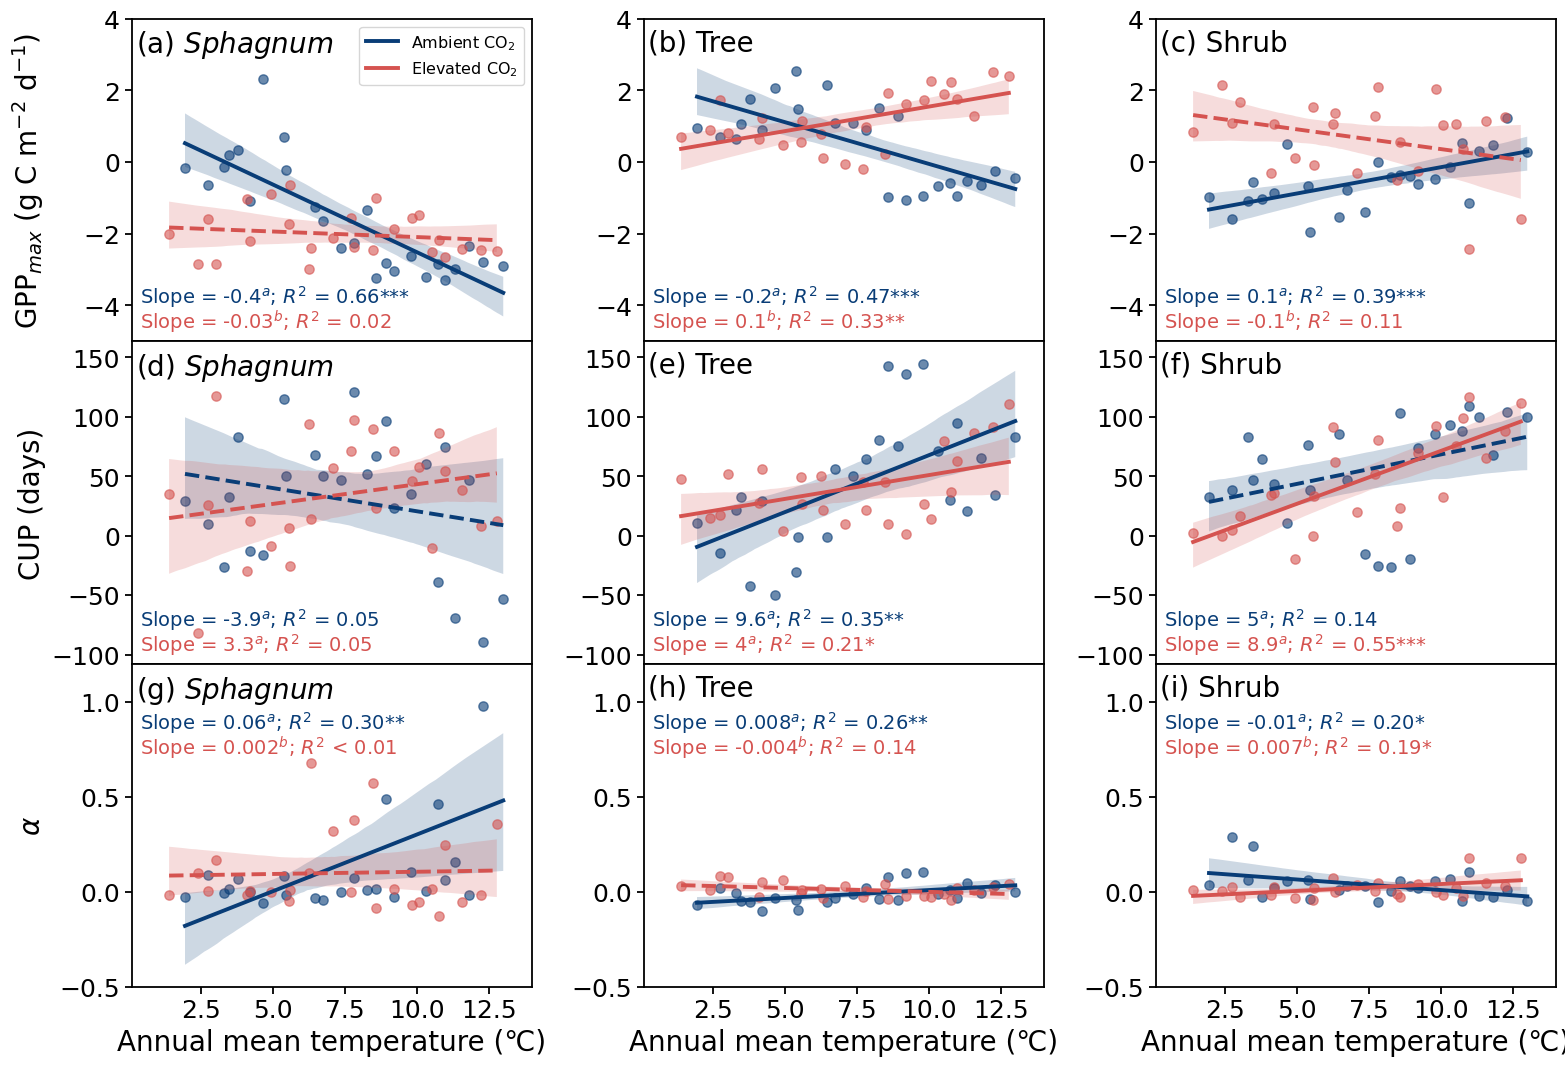

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.lines as mlines

# ============================================================
# 0) CONFIG
# ============================================================
BASE_DIR = "../../data_results/2_results/2-3_gppmax_cup_6methods/"
FILE_TEMPLATE = os.path.join(
    BASE_DIR,
    "calculated_GPPmax_CUP_ampFracs_10_20_30_25_thresholdScope_{pft}.xlsx"
)

YEAR_MIN = 2016

PFTS = ["sphagnum", "tree", "shrub"]
PFT_TITLES = [r"$\it{Sphagnum}$", "Tree", "Shrub"]

ROW_VARS = ["GPPmax", "CUP", "alpha"]
ROW_LABELS = {
    "GPPmax": "GPP$_{max}$",
    "CUP": "CUP",
    "alpha": r"$\alpha$"
}

CO2_COL = "co2"
X_COL = "temp_mean_anom"
ACO2 = 0
ECO2 = 500

BLUE = "#093D77"
RED = "#d55350"
X_TICKS = [2.5, 5, 7.5, 10, 12.5]

OUT_FIG = os.path.join(BASE_DIR, "Fig_3PFTs_GPPmax_CUP_alpha_3x3.png")


# ============================================================
# 1) HELPERS
# ============================================================
def replace_outliers_with_mean(x, y, method="zscore", threshold=3.0):
    """
    Replace outliers in y with group mean (based on x-y pairs)
    method: 'zscore' or 'iqr'
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    y_new = y.copy()

    if len(y) < 5:
        return x, y  

    if method == "zscore":
        z = (y - np.nanmean(y)) / np.nanstd(y)
        outliers = np.abs(z) > threshold

    elif method == "iqr":
        q1, q3 = np.percentile(y, [25, 75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = (y < lower) | (y > upper)

    else:
        raise ValueError("method must be 'zscore' or 'iqr'")

    mean_val = np.nanmean(y[~outliers])

    y_new[outliers] = mean_val

    return x, y_new

def style_ax(ax, labelsize=13):
    ax.tick_params(
        axis="both", which="major",
        labelsize=labelsize,
        length=5, width=1.3, direction="out",
        bottom=True, left=True
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def fmt_num(v, nd=1, tol=1e-8):
    if (v is None) or pd.isna(v) or (abs(float(v)) < tol):
        return "0"
    v = float(v)
    if abs(v) >= 1:
        return f"{v:.{nd}f}".rstrip("0").rstrip(".")
    return f"{v:.1g}"


def cal_reg_diff(x1, y1, x2, y2, alpha=0.05):
    """
    Test whether two slopes differ significantly:
    y ~ x + group + x:group
    """
    x1 = np.asarray(x1, float)
    y1 = np.asarray(y1, float)
    x2 = np.asarray(x2, float)
    y2 = np.asarray(y2, float)

    mask1 = np.isfinite(x1) & np.isfinite(y1)
    mask2 = np.isfinite(x2) & np.isfinite(y2)

    x1, y1 = x1[mask1], y1[mask1]
    x2, y2 = x2[mask2], y2[mask2]

    d = pd.DataFrame({
        "x": np.concatenate([x1, x2]),
        "y": np.concatenate([y1, y2]),
        "group": np.r_[np.repeat("aCO2", len(x1)), np.repeat("eCO2", len(x2))]
    })
    d["group"] = d["group"].astype("category")

    model = smf.ols("y ~ x + C(group) + x:C(group)", data=d).fit()

    term = [n for n in model.pvalues.index if ("x:C(group)" in n) or (":" in n and "x" in n)]
    if len(term) == 0:
        raise KeyError(f"Cannot identify interaction term. Terms: {list(model.pvalues.index)}")

    p_int = float(model.pvalues[term[0]])
    return ("a", "b") if p_int < alpha else ("a", "a")


def fit_linear(x, y, alpha=0.05):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {
            "model": None,
            "linestyle": "--",
            "stars": "",
            "b0": np.nan,
            "b1": np.nan,
            "r2": np.nan,
            "p_model": np.nan
        }

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    p_model = float(model.f_pvalue)
    linestyle = "-" if p_model < alpha else "--"
    stars = "***" if p_model < 0.001 else ("**" if p_model < 0.01 else ("*" if p_model < 0.05 else ""))

    b0, b1 = model.params
    r2 = float(model.rsquared)

    return {
        "model": model,
        "linestyle": linestyle,
        "stars": stars,
        "b0": b0,
        "b1": b1,
        "r2": r2,
        "p_model": p_model
    }


def eq_text_linear(fit, sup="a", nd_slope=1, nd_r2=2):
    b1s = fmt_num(fit["b1"], nd=nd_slope)
    r2 = fit["r2"]
    if pd.isna(r2):
        return f"Slope = NA$^{{{sup}}}$"

    r2s = f"{r2:.{nd_r2}f}"
    if r2 > 0.01:
        return f"Slope = {b1s}$^{{{sup}}}$; $R^2$ = {r2s}{fit['stars']}"
    return f"Slope = {b1s}$^{{{sup}}}$; $R^2$ < 0.01"


def draw_reg(ax, x, y, color, linestyle, scatter_alpha=0.60, line_alpha=1.0):
    sns.regplot(
        x=x, y=y, ax=ax,
        order=1, ci=95,
        scatter_kws={"alpha": scatter_alpha, "color": color, "s": 45},
        line_kws={"linestyle": linestyle, "alpha": line_alpha, "linewidth": 2.8},
        color=color
    )
    if len(ax.collections) > 1:
        ax.collections[-1].set_alpha(0.20)


def find_first_existing(df, candidates, pft=None):
    """
    Return the first existing column in candidates.
    Supports {pft} placeholder.
    """
    for c in candidates:
        cc = c.format(pft=pft) if pft is not None else c
        if cc in df.columns:
            return cc
    raise KeyError(f"Cannot find any matching column. Candidates: {candidates}")


def get_var_column(df, var_name, pft):
    """
    Try to detect the appropriate column name automatically.
    You can move your preferred candidate to the front if needed.
    """
    candidates = {
        "GPPmax": [
            "gppmax_whsM_25_anom",
            "GPPmax_whsM_25_anom",
            "{pft}_gppmax_whsM_25_anom",
            "gppmax_anom",
            "GPPmax_anom",
            "{pft}_gppmax_anom",
            "gpp_max_anom",
            "{pft}_gpp_max_anom",
            "gpp_max_whsM_anom",
        ],
        "CUP": [
            "cup_whsM_25_anom",
            "CUP_whsM_25_anom",
            "{pft}_cup_whsM_25_anom",
            "cup_anom",
            "CUP_anom",
            "{pft}_cup_anom",
            "cup_whsM_25_anom"
        ],
        "alpha": [
            "alpha_whsM_25_anom",
            "alpha_anom",
            "{pft}_alpha_whsM_25_anom",
            "{pft}_alpha_anom",
            "ampFrac_whsM_25_anom",
            "ampFrac_anom",
            "ampfrac_whsM_25_anom",
            "ampfrac_anom",
            "{pft}_ampFrac_whsM_25_anom",
            "{pft}_ampFrac_anom",
            "{pft}_ampfrac_whsM_25_anom",
            "{pft}_ampfrac_anom",
            "alpha_whsM_25_anom"
        ]
    }
    return find_first_existing(df, candidates[var_name], pft=pft)


# ============================================================
# 2) READ ALL DATA + DETECT COLUMNS
# ============================================================
data_dict = {}
ylims = {}

for pft in PFTS:
    file_path = FILE_TEMPLATE.format(pft=pft)
    df = pd.read_excel(file_path)
    df = df[df["year"] > YEAR_MIN].copy()

    if X_COL not in df.columns or CO2_COL not in df.columns:
        raise KeyError(f"{pft}: missing {X_COL} or {CO2_COL}")

    col_map = {}
    for var in ROW_VARS:
        col_map[var] = get_var_column(df, var, pft)

    data_dict[pft] = {
        "df": df,
        "cols": col_map
    }

    print(f"\n[{pft}] detected columns:")
    for k, v in col_map.items():
        print(f"  {k}: {v}")

# global y-limits for each row
for var in ROW_VARS:
    vals = []
    for pft in PFTS:
        df = data_dict[pft]["df"]
        col = data_dict[pft]["cols"][var]
        arr = df[col].to_numpy(float)
        arr = arr[np.isfinite(arr)]
        vals.append(arr)

    vals = np.concatenate(vals)
    ymin, ymax = np.min(vals), np.max(vals)
    yr = ymax - ymin
    pad = 0.08 * yr if yr > 0 else 1.0
    ylims[var] = (ymin - pad, ymax + pad)

# ["GPPmax", "CUP", "alpha"]
ylims["GPPmax"] = (-5, 4)
# ylims["CUP"]    = ()
ylims["alpha"]  = (-0.5, 1.2)

# ============================================================
# 3) FIGURE SETTINGS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)

# manual text positions by row
text_pos = {
    "GPPmax": ((0.02, 0.1), (0.02, 0.02)),
    "CUP":    ((0.02, 0.1), (0.02, 0.02)),
    "alpha":  ((0.02, 0.78), (0.02, 0.7)),
}

# nice y-axis labels
ylabel_map = {
    "GPPmax": "GPP$_{max}$ (g C m$^{-2}$ d$^{-1}$)",
    "CUP": "CUP (days)",
    "alpha": r"$\alpha$"
}
# subtitle
panel_letter = [["(a)", "(b)", "(c)"], ["(d)", "(e)", "(f)"], ["(g)", "(h)", "(i)"]]

# ============================================================
# 4) PLOT
# ============================================================
for irow, var in enumerate(ROW_VARS):
    for icol, pft in enumerate(PFTS):
        ax = axes[irow, icol]

        df = data_dict[pft]["df"]
        y_col = data_dict[pft]["cols"][var]

        d1 = df[df[CO2_COL] == ACO2].copy()
        d2 = df[df[CO2_COL] == ECO2].copy()

        x1_raw = d1[X_COL].to_numpy(float)
        y1_raw = d1[y_col].to_numpy(float)

        x2_raw = d2[X_COL].to_numpy(float)
        y2_raw = d2[y_col].to_numpy(float)

        x1, y1 = replace_outliers_with_mean(x1_raw, y1_raw, method="zscore", threshold=3)
        x2, y2 = replace_outliers_with_mean(x2_raw, y2_raw, method="zscore", threshold=3)

        # slope difference between aCO2 and eCO2
        sup1, sup2 = cal_reg_diff(x1, y1, x2, y2, alpha=0.05)

        # fit
        fit1 = fit_linear(x1, y1, alpha=0.05)
        fit2 = fit_linear(x2, y2, alpha=0.05)

        # draw
        draw_reg(ax, x1, y1, color=BLUE, linestyle=fit1["linestyle"])
        draw_reg(ax, x2, y2, color=RED, linestyle=fit2["linestyle"])

        # axes
        ax.set_xlim(0.1, 14)
        ax.set_xticks(X_TICKS)
        ax.set_ylim(ylims[var])
        style_ax(ax, labelsize=18)

        ax.text(
            0.01, 0.97,
            f"{panel_letter[irow][icol]} {PFT_TITLES[icol]}",
            transform=ax.transAxes, fontsize=20,
            va="top", ha="left"
        )

        # row label on first column only
        if icol == 0:
            ax.set_ylabel(ylabel_map[var], fontsize=20)

        # x label only on bottom row
        if irow == 2:
            ax.set_xlabel("Annual mean temperature (℃)", fontsize=20)

        # eq text
        (tx_blue, ty_blue), (tx_red, ty_red) = text_pos[var]
        ax.text(
            tx_blue, ty_blue,
            eq_text_linear(fit1, sup=sup1),
            fontsize=14, transform=ax.transAxes,
            color=BLUE, va="bottom"
        )
        ax.text(
            tx_red, ty_red,
            eq_text_linear(fit2, sup=sup2),
            fontsize=14, transform=ax.transAxes,
            color=RED, va="bottom"
        )

# ============================================================
# 5) LEGEND
# ============================================================
blue_line = mlines.Line2D([], [], color=BLUE, linestyle="-", linewidth=2.8, label="Ambient CO$_2$")
red_line  = mlines.Line2D([], [], color=RED,  linestyle="-", linewidth=2.8, label="Elevated CO$_2$")

axes[0, 0].legend(
    handles=[blue_line, red_line],
    loc="upper right",
    # bbox_to_anchor=(0.02, 0.82),
    fontsize=11.5,
    # frameon=False,
    # handlelength=1.2,
    # handletextpad=0.6,
    # labelspacing=0.4,
    # borderpad=0.2
)

# align ylabels
fig.align_ylabels()

plt.subplots_adjust(wspace=0.28, hspace=0, left=0.09, right=0.98, bottom=0.08, top=0.96)
# plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()